Irene Lega, Benedetta Taricco, Matteo Gobbato. 
# Top Quark Tagging, notebook 1.
# PRIMA IMPLEMENTAZIONE

In questo notebook si realizzano due sistemi di quantum machine lerning per la classificazione dei quark top utilizzando il dataset fornito dall'esperimento ATLAS del CERN. \
In entrambi i casi si usa un VQA con PQC. Come loss function si usa la BCE e come ottimizzatore classico ADAM. Si usano 8 qubits e 8 features per jet: ad ogni feature corrisponde un qubit.\
Nel primo caso si studia il comportamento di un PQC semplice, con angle encoding e due layer di rotazioni e CNOT. Nel secondo caso si prova ad implementare un circuito molto più complesso, con diversi tipi di encoding, porte IsingZZ e applicazione di funzioni non lineari.

# Autoencoder

Prima di tutto, si preprocessano le low level features e se ne selezionano 8 attraverso un autoencoder sinkhorn. Questo valore è stato scelto come equilibrio tra la massimizzazione dell'informazione nella compressione dati e la minimizzazione del numero di qubits del circuito. Variandolo, le performance cambiano. Il dataset viene poi diviso in train e test:

DataLoader pronto! Numero batch: 40

Training AE | latent=8, early_stop=30

  ✓ new best: 1.44120
Epoch 1/200 | train=1.49774  valid=1.44120  recon=0.95629  sink=0.00025  cls=0.69263  [!] cls~random
  ✓ new best: 1.39915
Epoch 2/200 | train=1.47997  valid=1.39915  recon=0.94503  sink=0.04657  cls=0.62879
  ✓ new best: 1.17893
Epoch 3/200 | train=1.32117  valid=1.17893  recon=0.75569  sink=0.04053  cls=0.58726
  ✓ new best: 1.12468
Epoch 4/200 | train=1.17706  valid=1.12468  recon=0.71853  sink=0.03355  cls=0.56583
  ✓ new best: 1.08783
Epoch 5/200 | train=1.14794  valid=1.08783  recon=0.69768  sink=0.01269  cls=0.55191
  ✓ new best: 1.07366
Epoch 6/200 | train=1.10952  valid=1.07366  recon=0.69024  sink=0.01594  cls=0.54091
  ✓ new best: 1.05059
Epoch 7/200 | train=1.06660  valid=1.05059  recon=0.66896  sink=0.01314  cls=0.53956
  ✓ new best: 1.04010
Epoch 8/200 | train=1.05882  valid=1.04010  recon=0.66020  sink=0.01547  cls=0.53609
  ✓ new best: 1.02869
Epoch 9/200 | train=1.04332  v

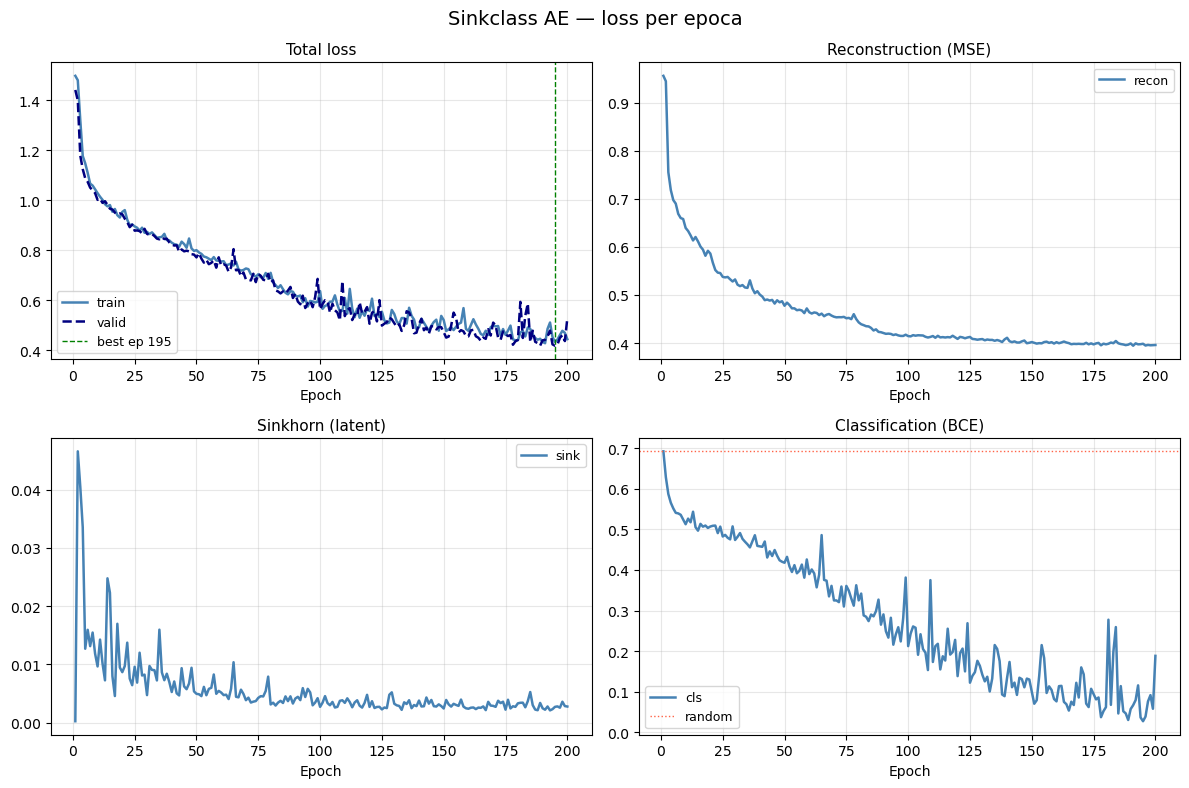

X_tr shape: (8000, 400)
X_te shape: (2000, 400)
latent_train shape: (8000, 8)
latent_test shape: (2000, 8)
X_train shape: (8000, 8)
X_test shape: (2000, 8)


In [1]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import geomloss
import matplotlib.pyplot as plt
import os
import pennylane as qml
import pennylane.numpy as pnp
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# ================================================================
# PARTE 1 — CARICA DATI
# ================================================================

infile = "train_nominal_000.h5"
f = h5py.File(infile, 'r')
Njet = 10000
NConstituents = 100

clus_E   = f['fjet_clus_E'][:Njet,   :NConstituents]
clus_eta = f['fjet_clus_eta'][:Njet,  :NConstituents]
clus_phi = f['fjet_clus_phi'][:Njet,  :NConstituents]
clus_pt  = f['fjet_clus_pt'][:Njet,   :NConstituents]
labels   = f["labels"][:Njet]

X = np.concatenate([
    clus_pt.reshape(Njet, -1),
    clus_eta.reshape(Njet, -1),
    clus_phi.reshape(Njet, -1),
    clus_E.reshape(Njet, -1)
], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.float32)
dataset  = TensorDataset(X_tensor, y_tensor)

train_loader = DataLoader(dataset, batch_size=256, shuffle=True)
valid_loader = DataLoader(dataset, batch_size=512, shuffle=False)
print("DataLoader pronto! Numero batch:", len(train_loader))


# ================================================================
# PARTE 2 — AUTOENCODER SINKCLASS
# ================================================================

class AE_sinkclass(nn.Module):
    def __init__(self, device="cpu", hpars=None):
        super().__init__()
        self.device = device
        self.hp = {
            "ae_type":          "sinkclass",
            "ae_layers":        [400, 256, 128, 64, 32, 16, 8],  # latent = 16
            "lr":               0.0005,
            "adam_betas":       (0.9, 0.999),
            "labels_dimension": 2,
            "class_weight":     0.7,
            "sinkh_weight":     0.3,
            "class_layers":     [64, 32, 16, 1],
        }
        if hpars:
            self.hp.update({k: hpars[k] for k in hpars.keys() & self.hp.keys()})

        latent_dim = self.hp["ae_layers"][-1]   # 16
        labels_dim = self.hp["labels_dimension"]

        self.encoder    = self._build_mlp(self.hp["ae_layers"], final_activation=False)
        self.decoder    = self._build_mlp(list(reversed(self.hp["ae_layers"])), final_activation=True)
        self.classifier = self._build_classifier([latent_dim] + self.hp["class_layers"])

        first_hidden = self.hp["ae_layers"][1]
        self.noise_enc_data = nn.Sequential(
            nn.Linear(self.hp["ae_layers"][0], first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden),            nn.LeakyReLU(0.2),
        )
        self.noise_enc_labl = nn.Sequential(
            nn.Linear(labels_dim, first_hidden), nn.LeakyReLU(0.2),
        )
        self.noise_gen = nn.Sequential(
            nn.Linear(2 * first_hidden, first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden // 2),  nn.LeakyReLU(0.2),
            nn.Linear(first_hidden // 2, latent_dim),
        )

        self.recon_loss_fn = nn.MSELoss(reduction="mean")
        self.class_loss_fn = nn.BCELoss(reduction="mean")
        self.laten_loss_fn = geomloss.SamplesLoss("sinkhorn", blur=0.05, scaling=0.95, diameter=0.01, debias=True)

        self.best_valid_loss   = float("inf")
        self.epochs_no_improve = 0
        self.early_stop_limit  = 30
        self.all_train_loss, self.all_valid_loss = [], []
        self.all_recon_loss, self.all_laten_loss, self.all_class_loss = [], [], []
        self.to(self.device)

    @staticmethod
    def _build_mlp(layers, final_activation=True):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.ReLU(True))
            elif final_activation:
                mods.append(nn.Tanh())
        return nn.Sequential(*mods)

    @staticmethod
    def _build_classifier(layers):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            mods.append(nn.Sigmoid() if i == len(layers) - 2 else nn.LeakyReLU(0.2))
        return nn.Sequential(*mods)

    def _onehot(self, y_batch):
        B = y_batch.shape[0]
        y_map = torch.zeros(B, self.hp["labels_dimension"], device=y_batch.device)
        return y_map.scatter_(1, y_batch.long().reshape(-1, 1), 1.0)

    def _generate_noise(self, x_noise, y_onehot):
        return self.noise_gen(torch.cat([self.noise_enc_data(x_noise),
                                         self.noise_enc_labl(y_onehot)], dim=1))

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.classifier(latent), self.decoder(latent)

    def compute_loss(self, x_data, y_data):
        y_onehot     = self._onehot(y_data)
        latent, classif, recon = self.forward(x_data)
        latent_noise = self._generate_noise(torch.rand_like(x_data), y_onehot)
        recon_loss   = self.recon_loss_fn(recon, x_data)
        class_loss   = self.class_loss_fn(classif.flatten(), y_data.float())
        laten_loss   = self.laten_loss_fn(latent, latent_noise)
        return (recon_loss + self.hp["sinkh_weight"] * laten_loss
                + self.hp["class_weight"] * class_loss,
                recon_loss, laten_loss, class_loss)

    def train_autoencoder(self, train_loader, valid_loader, epochs=200, outdir=None):
        optimizer = optim.Adam(self.parameters(), lr=self.hp["lr"], betas=self.hp["adam_betas"])
        print(f"\nTraining AE | latent={self.hp['ae_layers'][-1]}, early_stop={self.early_stop_limit}\n")
        for epoch in range(epochs):
            self.train()
            batch_sum, n = 0.0, 0
            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                total, *_ = self.compute_loss(xb, yb)
                optimizer.zero_grad(); total.backward(); optimizer.step()
                batch_sum += total.item(); n += 1
            train_loss = batch_sum / n
            vt, vr, vl, vc = self._validate(valid_loader, outdir)
            self.all_train_loss.append(train_loss); self.all_valid_loss.append(vt)
            self.all_recon_loss.append(vr);         self.all_laten_loss.append(vl)
            self.all_class_loss.append(vc)
            warn = "  [!] cls~random" if vc > 0.68 else ""
            print(f"Epoch {epoch+1}/{epochs} | train={train_loss:.5f}  valid={vt:.5f}  "
                  f"recon={vr:.5f}  sink={vl:.5f}  cls={vc:.5f}{warn}")
            if self.epochs_no_improve >= self.early_stop_limit:
                print(f"Early stopping at epoch {epoch+1}."); break

    @torch.no_grad()
    def _validate(self, valid_loader, outdir):
        self.eval()
        xv, yv = next(iter(valid_loader))
        xv, yv = xv.to(self.device), yv.to(self.device)
        total, r, l, c = self.compute_loss(xv, yv)
        if total.item() < self.best_valid_loss:
            self.best_valid_loss = total.item(); self.epochs_no_improve = 0
            print(f"  ✓ new best: {self.best_valid_loss:.5f}")
            if outdir:
                os.makedirs(outdir, exist_ok=True)
                torch.save(self.state_dict(), f"{outdir}/best_model.pt")
        else:
            self.epochs_no_improve += 1
        return total.item(), r.item(), l.item(), c.item()

    def loss_plot(self, outdir=None):
        epochs = list(range(1, len(self.all_train_loss) + 1))
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle("Sinkclass AE — loss per epoca", fontsize=14)
        for ax, s1, s2, title, l1, l2 in [
            (axes[0,0], self.all_train_loss, self.all_valid_loss, "Total loss",              "train", "valid"),
            (axes[0,1], self.all_recon_loss,  None,               "Reconstruction (MSE)",    "recon", None),
            (axes[1,0], self.all_laten_loss,  None,               "Sinkhorn (latent)",       "sink",  None),
            (axes[1,1], self.all_class_loss,  None,               "Classification (BCE)",    "cls",   None),
        ]:
            ax.plot(epochs, s1, color="steelblue", linewidth=1.8, label=l1)
            if s2: ax.plot(epochs, s2, color="navy", linewidth=1.8, linestyle="--", label=l2)
            if "Classification" in title:
                ax.axhline(0.693, color="tomato", linewidth=1, linestyle=":", label="random")
            ax.set_title(title, fontsize=11); ax.set_xlabel("Epoch")
            ax.legend(fontsize=9); ax.grid(alpha=0.3)
        best_ep = int(np.argmin(self.all_valid_loss)) + 1
        axes[0,0].axvline(best_ep, color="green", linewidth=1, linestyle="--",
                          label=f"best ep {best_ep}"); axes[0,0].legend(fontsize=9)
        plt.tight_layout()
        if outdir:
            os.makedirs(outdir, exist_ok=True)
            plt.savefig(os.path.join(outdir, "loss_epochs.pdf"))
        plt.show(); plt.close()


# addestra il modello
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = AE_sinkclass(device=device)
model.train_autoencoder(train_loader, valid_loader, epochs=200, outdir="risultati")
model.loss_plot(outdir="risultati")


# ================================================================
# PARTE 3 — PONTE: latent array dal tuo X e labels
# ================================================================

X_tr, X_te, Y_tr, Y_te = train_test_split(X, labels, test_size=0.2, random_state=42)

with torch.no_grad():
    latent_train = model.encoder(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    latent_test  = model.encoder(torch.tensor(X_te, dtype=torch.float32)).numpy()

# latent shape: (N, 16) — scala in [0, pi] con sigmoid
X_train = pnp.array(1 / (1 + np.exp(-latent_train)) * np.pi)
X_test  = pnp.array(1 / (1 + np.exp(-latent_test))  * np.pi)
Y_train = pnp.array(np.where(Y_tr == 1,  1, -1).astype(np.float64))
Y_test  = pnp.array(np.where(Y_te == 1,  1, -1).astype(np.float64))

print("X_tr shape:", X_tr.shape)          # 8000, 400
print("X_te shape:", X_te.shape)          
print("latent_train shape:", latent_train.shape)  # 8000, 16
print("latent_test shape:", latent_test.shape)
print("X_train shape:", X_train.shape)  
print("X_test shape:", X_test.shape)  


# Circuito semplice

Passiamo ora al primo circuito: si definiscono le funzioni e la loss function per creare il modello. Il valore del learning rate è stato selezionato a tentativi.

In [15]:
# 8 QUBITS, 8 FEATURES, NO RE-UPLOADING, codice poco espressivo

from catalyst import qjit
import pennylane as qml
from jax import numpy as jnp
import jax.numpy as jnp


n_qubits      = 8
steps         = 400
lr_init = 0.1
batch_size=20

dev = qml.device("default.qubit", wires=n_qubits)

# DEFINIZIONI 

def structured_ansatz(weights, wires): #layer
    n = len(wires)
    for i in range(n):
        qml.RY(weights[i, 0], wires=wires[i])
        qml.RZ(weights[i, 1], wires=wires[i])
    for i in range(0, n - 1, 2):
        qml.CNOT(wires=[wires[i], wires[i + 1]])
    for i in range(1, n - 1, 2):
        qml.CNOT(wires=[wires[i], wires[i + 1]])


def pqc(weights, x_sample):
    x = x_sample.flatten()

    for i in range(n_qubits): #encoding lineare
        qml.RY(x[i],      wires=i)
        
    for i in range(2):
        structured_ansatz(weights[i], wires=range(n_qubits)) #2 layers


@qml.qnode(dev, interface="autograd")
def predict(weights, x_sample):
    pqc(weights, x_sample)
    return (qml.expval(qml.PauliZ(0))) #misura solo il primo qubit



def cost_function(weights, X, Y, batch_size, eps=1e-7): #BCE
    Y_arr   = np.array(Y)
    idx_pos = np.where(Y_arr ==  1)[0]
    idx_neg = np.where(Y_arr == -1)[0]
    half    = batch_size // 2

    chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
    chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
    idx = np.concatenate([chosen_pos, chosen_neg])
    np.random.shuffle(idx)

    X_batch = pnp.array(X[idx])
    Y_batch = pnp.array((Y_arr[idx] + 1) / 2) 

    preds_raw = pnp.array([predict(weights, x) for x in X_batch])

    probs = (preds_raw + 1) / 2          
    probs = pnp.clip(probs, eps, 1 - eps)

    return -pnp.mean(
        Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
    )


weights = pnp.array(
    pnp.random.uniform(-0.05, 0.05, size=(2, n_qubits, 2)), #inizializzazione pesi vicino a zero
    requires_grad=True
) #2x8x2 weights (uno per ogni rotazione per ogni qubit per ogni layer)


print(f"Parametri totali: {weights.size}")
print(f"  Shape: {weights.shape} = (2 blocchi, {n_qubits} qubit, 2 angoli)")




Parametri totali: 32
  Shape: (2, 8, 2) = (2 blocchi, 8 qubit, 2 angoli)


Ora si può definire il training loop:

In [16]:
# TRAINING

print(f"Steps {steps}, Learning rate {lr_init}, Batch size {batch_size}\n")

opt = qml.AdamOptimizer(stepsize=lr_init)

loss_history = []
acc_history  = []
best_acc     = 0.0
best_weights = pnp.array(weights)

for i in range(steps):

    weights, cost_val = opt.step_and_cost(
        lambda w: cost_function(w, X_train, Y_train, batch_size=batch_size),
        weights
    )
    loss_history.append(float(cost_val))

    if i % 10 == 0: #per plot
        val_idx   = np.random.choice(len(X_test), size=200, replace=False)
        val_preds = [1 if predict(weights, x) >= 0 else -1 for x in X_test[val_idx]]
        val_acc   = float(np.mean(np.array(val_preds) == np.array(Y_test[val_idx])))
        acc_history.append((i, val_acc))

        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = pnp.array(weights)

        print(f"Step {i:3d}, Cost {cost_val:.4f}, Val acc {val_acc:.3f}")

print(f"\nMigliore val acc: {best_acc:.3f}")
weights = best_weights


Steps 400, Learning rate 0.1, Batch size 20

Step   0, Cost 0.7326, Val acc 0.385
Step  10, Cost 0.7404, Val acc 0.405
Step  20, Cost 0.7380, Val acc 0.335
Step  30, Cost 0.6954, Val acc 0.525
Step  40, Cost 0.6402, Val acc 0.880
Step  50, Cost 0.6222, Val acc 0.865
Step  60, Cost 0.6456, Val acc 0.860
Step  70, Cost 0.6206, Val acc 0.850
Step  80, Cost 0.6509, Val acc 0.755
Step  90, Cost 0.6145, Val acc 0.880
Step 100, Cost 0.6413, Val acc 0.820
Step 110, Cost 0.6285, Val acc 0.815
Step 120, Cost 0.6234, Val acc 0.865
Step 130, Cost 0.6318, Val acc 0.850
Step 140, Cost 0.6391, Val acc 0.830
Step 150, Cost 0.6288, Val acc 0.860
Step 160, Cost 0.6340, Val acc 0.850
Step 170, Cost 0.6354, Val acc 0.905
Step 180, Cost 0.6284, Val acc 0.845
Step 190, Cost 0.6464, Val acc 0.880
Step 200, Cost 0.6231, Val acc 0.865
Step 210, Cost 0.6197, Val acc 0.825
Step 220, Cost 0.6440, Val acc 0.860
Step 230, Cost 0.6339, Val acc 0.850
Step 240, Cost 0.6109, Val acc 0.865
Step 250, Cost 0.6203, Val acc

e plottare l'andamento del training:

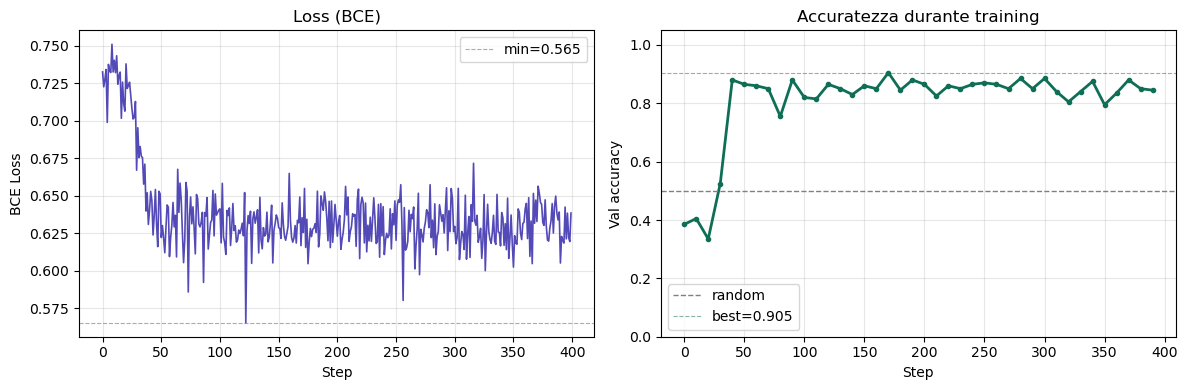


Loss iniziale: 0.7326
Loss finale:   0.6385
Riduzione:     0.0941 (12.8%)


In [17]:
# PLOT TRAINING

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color="#534AB7", linewidth=1.2)
axes[0].axhline(min(loss_history), color="#534AB7", linewidth=0.8,
                linestyle="--", alpha=0.5, label=f"min={min(loss_history):.3f}")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss (BCE)"); axes[0].legend(); axes[0].grid(alpha=0.3)

steps_a, accs_a = zip(*acc_history) if acc_history else ([], [])
axes[1].plot(steps_a, accs_a, color="#0F6E56", linewidth=2, marker="o", markersize=3)
axes[1].axhline(0.5, color="gray", linewidth=1, linestyle="--", label="random")
axes[1].axhline(best_acc, color="#0F6E56", linewidth=0.8, linestyle="--",
                alpha=0.5, label=f"best={best_acc:.3f}")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Accuratezza durante training")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLoss iniziale: {loss_history[0]:.4f}")
print(f"Loss finale:   {loss_history[-1]:.4f}")
print(f"Riduzione:     {loss_history[0]-loss_history[-1]:.4f} "
      f"({(1-loss_history[-1]/loss_history[0])*100:.1f}%)")

Si applica ora il modello al dataset di test e si valuta la performance:



  AE SINKCLASS — classificatore classico (BCE)
  Accuracy AE classifier : 93.45%
  AUC      AE classifier : 0.9934
  Score medio su signal  : 0.9815
  Score medio su bkg     : 0.1374


  PQC — classificatore quantistico
  Accuracy  : 85.80%
  AUC       : 0.9469
  Precision : 0.8357
  Recall    : 0.9074
  Cost test : 0.6320


  Matrice di confusione (righe=real, colonne=pred):

               pred+1  pred-1
  real  +1  :    951      97
  real  -1  :    187     765

  Score PQC medio su signal : 0.0664
  Score PQC medio su bkg    : -0.0676




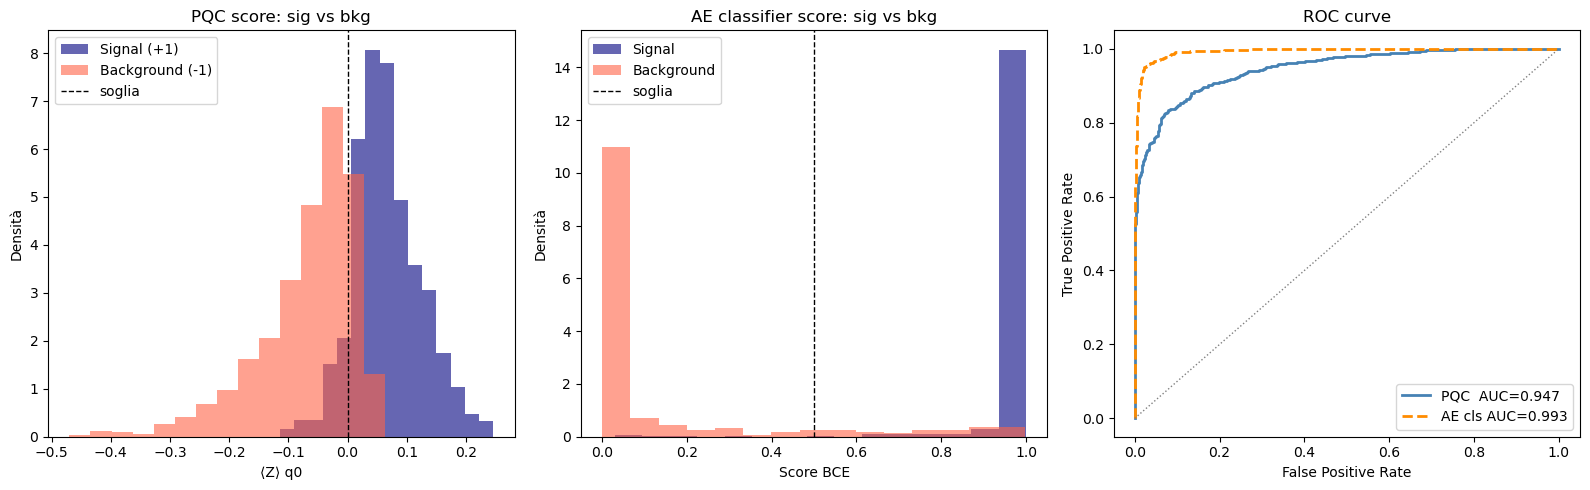

In [19]:
# TEST

test_predictions = [float(predict(weights, x)) for x in X_test]


# EVALUATION TEST

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

pred_labels = [1 if p >= 0 else -1 for p in test_predictions]
scores_np   = np.array([float(p) for p in test_predictions])
Y_test_np   = np.array(Y_test)
pred_np     = np.array(pred_labels)

accuracy  = np.mean(pred_np == Y_test_np)
test_cost = cost_function(weights, X_test, Y_test, batch_size)

# AUC (converti -1/+1 → 0/1 per sklearn)
Y_bin = ((Y_test_np + 1) / 2).astype(int)
s_bin = (scores_np + 1) / 2
auc   = roc_auc_score(Y_bin, s_bin)
fpr, tpr, _ = roc_curve(Y_bin, s_bin)

cm = confusion_matrix(Y_test_np, pred_np, labels=[1,-1])
TP, FN = cm[0,0], cm[0,1]
FP, TN = cm[1,0], cm[1,1]
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0

# AE classifier (dal modello classico)
print("")
print("")
print("  AE SINKCLASS — classificatore classico (BCE)")

with torch.no_grad():
    _, ae_scores, _ = model.forward(torch.tensor(X_te, dtype=torch.float32))
    ae_scores_np = ae_scores.cpu().numpy().flatten()
ae_pred  = (ae_scores_np >= 0.5).astype(int)
ae_acc   = np.mean(ae_pred == Y_te.astype(int))
ae_auc   = roc_auc_score(Y_te.astype(int), ae_scores_np)
print(f"  Accuracy AE classifier : {ae_acc*100:.2f}%")
print(f"  AUC      AE classifier : {ae_auc:.4f}")
print(f"  Score medio su signal  : {ae_scores_np[Y_te==1].mean():.4f}")
print(f"  Score medio su bkg     : {ae_scores_np[Y_te==0].mean():.4f}")

# valori PQC 
print("")
print("")
print("  PQC — classificatore quantistico")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  AUC       : {auc:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  Cost test : {test_cost:.4f}")
print("")
print(f"\n  Matrice di confusione (righe=real, colonne=pred):")
print("")
print(f"               pred+1  pred-1")
print(f"  real  +1  :  {TP:5d}   {FN:5d}")
print(f"  real  -1  :  {FP:5d}   {TN:5d}")
print(f"\n  Score PQC medio su signal : {scores_np[Y_test_np== 1].mean():.4f}")
print(f"  Score PQC medio su bkg    : {scores_np[Y_test_np==-1].mean():.4f}")
print("")
print("")

# PLOT
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafico score PQC sig vs bkg
axes[0].hist(scores_np[Y_test_np== 1], bins=15, alpha=0.6,
             color="navy",   label="Signal (+1)", density=True)
axes[0].hist(scores_np[Y_test_np==-1], bins=15, alpha=0.6,
             color="tomato", label="Background (-1)", density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="soglia")
axes[0].set_title("PQC score: sig vs bkg")
axes[0].set_xlabel("⟨Z⟩ q0")
axes[0].set_ylabel("Densità")
axes[0].legend()

# Grafico score AE classifier sig vs bkg
axes[1].hist(ae_scores_np[Y_te==1], bins=15, alpha=0.6,
             color="navy",   label="Signal", density=True)
axes[1].hist(ae_scores_np[Y_te==0], bins=15, alpha=0.6,
             color="tomato", label="Background", density=True)
axes[1].axvline(0.5, color="black", linewidth=1, linestyle="--", label="soglia")
axes[1].set_title("AE classifier score: sig vs bkg")
axes[1].set_xlabel("Score BCE")
axes[1].set_ylabel("Densità")
axes[1].legend()

# 3. ROC curve AE e PQC
axes[2].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"PQC  AUC={auc:.3f}")
ae_fpr, ae_tpr, _ = roc_curve(Y_te.astype(int), ae_scores_np)
axes[2].plot(ae_fpr, ae_tpr, color="darkorange", linewidth=2,
             linestyle="--", label=f"AE cls AUC={ae_auc:.3f}")
axes[2].plot([0,1], [0,1], color="gray", linewidth=1, linestyle=":")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

per stampare il circuito:

In [30]:
# PRINT CIRCUITO

print(qml.draw(predict)(weights, X_train))

0: ──RY(1.35)──RY(0.23)───RZ(0.01)──╭●──RY(2.35)──RZ(-0.04)────────────╭●────┤  <Z>
1: ──RY(1.64)──RY(-1.64)──RZ(0.01)──╰X─╭●─────────RY(-0.02)──RZ(0.04)──╰X─╭●─┤     
2: ──RY(1.49)──RY(-0.04)──RZ(-0.04)─╭●─╰X─────────RY(0.02)───RZ(0.05)──╭●─╰X─┤     
3: ──RY(1.63)──RY(-0.01)──RZ(0.01)──╰X─╭●─────────RY(-0.03)──RZ(0.01)──╰X─╭●─┤     
4: ──RY(1.88)──RY(0.02)───RZ(0.03)──╭●─╰X─────────RY(-0.04)──RZ(0.01)──╭●─╰X─┤     
5: ──RY(1.44)──RY(-0.02)──RZ(0.02)──╰X─╭●─────────RY(-0.03)──RZ(-0.00)─╰X─╭●─┤     
6: ──RY(1.65)──RY(0.03)───RZ(-0.04)─╭●─╰X─────────RY(0.03)───RZ(-0.02)─╭●─╰X─┤     
7: ──RY(1.59)──RY(-0.01)──RZ(0.04)──╰X──RY(0.04)──RZ(0.03)─────────────╰X────┤     


Si vede dagli indici di performance che questo modello non classifica in maniera soddisfacente. La causa si può attribuire alla poca espressività del codice: le operazioni sui qubit non bastano per simulare la complessità della classificazione ed esplorare tutto lo spazio del problema.

# Circuito espressivo

Si prova ora il circuito più complesso, quindi più espressivo (volutamente "troppo" espressivo). Ci si aspetta che la loss function faccia leggermente più fatica ad imparare (diminuire) ma che il classificatore sia più accurato. 
Seguendo la stessa struttura del caso precedente si implementano definizioni, training, andamento del training...

In [7]:
# 8 QUBITS, 8 FEATURES, NO RE-UPLOADING, codice volutamente troppo espressivo

from catalyst import qjit
import pennylane as qml
from jax import numpy as jnp
import jax.numpy as jnp


n_qubits      = 8
steps         = 400
lr_init = 0.01
batch_size=20

dev = qml.device("default.qubit", wires=n_qubits)

# DEFINIZIONI

def structured_ansatz(weights, wires): #layer
    n = len(wires)
    for i in range(n):
        qml.RY(weights[i, 0], wires=wires[i])
        qml.RZ(weights[i, 1], wires=wires[i])
    for i in range(0, n - 1, 2):
        qml.CNOT(wires=[wires[i], wires[i + 1]])
    for i in range(1, n - 1, 2):
        qml.CNOT(wires=[wires[i], wires[i + 1]])


def pqc(weights, x_sample):
    x = x_sample.flatten()

    for i in range(n_qubits): #encoding lineare e quadratico
        qml.RY(x[i],      wires=i)
        qml.RZ(x[i] ** 2, wires=i)

    for i in range(n_qubits): #encoding trigonometrico
        qml.RY(pnp.sin(x[i]), wires=i)
        qml.RZ(pnp.tanh(x[i]), wires=i)
    for i in range(n_qubits - 1):
        qml.IsingZZ(x[i] * x[i + 1], wires=[i, i + 1])
  
    for i in range(n_qubits):
        qml.RY(x[i] * pnp.pi / 2, wires=i)
        qml.RZ(pnp.tanh(x[i]),    wires=i)
    for i in range(n_qubits - 1):
        qml.IsingZZ(x[i] * x[i + 1], wires=[i, i + 1])
        
    for i in range(3):
        structured_ansatz(weights[i], wires=range(n_qubits))#3 layers


@qml.qnode(dev, interface="autograd")
def circuit(weights, x_sample):
    pqc(weights, x_sample)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)] #si misura un array di valori, uno per bit


def predict(weights, x_sample):
    return pnp.mean(pnp.array(circuit(weights, x_sample))) #media di tutti i bit => una predizione


def cost_function(weights, X, Y, batch_size, eps=1e-7): #BCE
    Y_arr   = np.array(Y)
    idx_pos = np.where(Y_arr ==  1)[0]
    idx_neg = np.where(Y_arr == -1)[0]
    half    = batch_size // 2

    chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
    chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
    idx = np.concatenate([chosen_pos, chosen_neg])
    np.random.shuffle(idx)

    X_batch = pnp.array(X[idx])
    Y_batch = pnp.array((Y_arr[idx] + 1) / 2) # +1,-1 -> 1,0

    preds_raw = pnp.array([predict(weights, x) for x in X_batch])

    probs = (preds_raw + 1) / 2 # -1,+1 -> 0,1
    probs = pnp.clip(probs, eps, 1 - eps)

    return -pnp.mean(
        Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
    )


weights = pnp.array(
    pnp.random.uniform(-0.05, 0.05, size=(3, n_qubits, 2)), #inizializzazione pesi vicino a zero
    requires_grad=True
) #3x8x2 weights (uno per ogni rotazione per ogni qubit per ogni layer)


print(f"Parametri totali: {weights.size}")
print(f"  Shape: {weights.shape} = (3 blocchi, {n_qubits} qubit, 2 angoli)")

Parametri totali: 48
  Shape: (3, 8, 2) = (3 blocchi, 8 qubit, 2 angoli)


Steps 400, Learning rate 0.01, Batch size 20

Step   0, Cost 0.6934, Val acc 0.450
Step  10, Cost 0.6681, Val acc 0.490
Step  20, Cost 0.6674, Val acc 0.620
Step  30, Cost 0.6461, Val acc 0.775
Step  40, Cost 0.6292, Val acc 0.885
Step  50, Cost 0.6289, Val acc 0.890
Step  60, Cost 0.6217, Val acc 0.925
Step  70, Cost 0.5850, Val acc 0.955
Step  80, Cost 0.5895, Val acc 0.945
Step  90, Cost 0.6085, Val acc 0.945
Step 100, Cost 0.6086, Val acc 0.940
Step 110, Cost 0.5948, Val acc 0.920
Step 120, Cost 0.5925, Val acc 0.945
Step 130, Cost 0.6023, Val acc 0.920
Step 140, Cost 0.6211, Val acc 0.930
Step 150, Cost 0.5811, Val acc 0.930
Step 160, Cost 0.5861, Val acc 0.950
Step 170, Cost 0.5874, Val acc 0.940
Step 180, Cost 0.6039, Val acc 0.930
Step 190, Cost 0.6088, Val acc 0.950
Step 200, Cost 0.5994, Val acc 0.940
Step 210, Cost 0.6027, Val acc 0.950
Step 220, Cost 0.5771, Val acc 0.935
Step 230, Cost 0.5624, Val acc 0.915
Step 240, Cost 0.6096, Val acc 0.870
Step 250, Cost 0.5714, Val ac

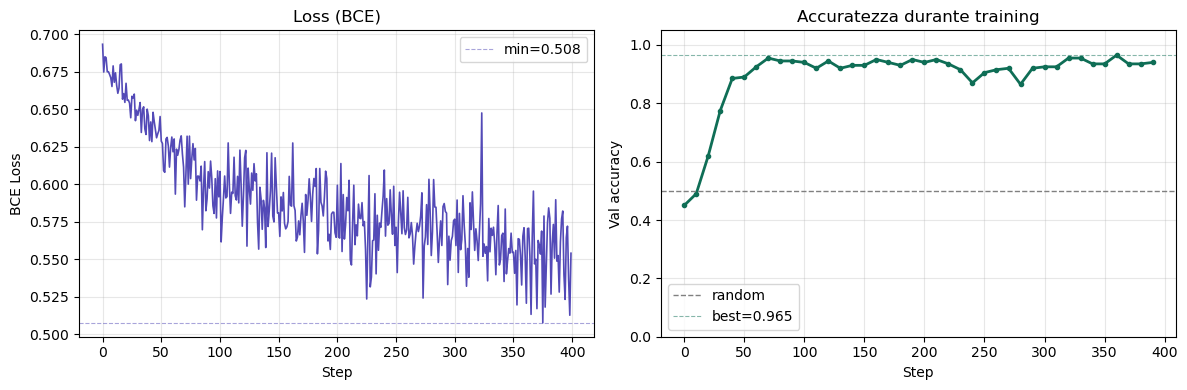


Loss iniziale: 0.6934
Loss finale:   0.5541
Riduzione:     0.1394 (20.1%)


In [8]:
# TRAINING

print(f"Steps {steps}, Learning rate {lr_init}, Batch size {batch_size}\n")

opt = qml.AdamOptimizer(stepsize=lr_init)

loss_history = []
acc_history  = []
best_acc     = 0.0
best_weights = pnp.array(weights)

for i in range(steps):

    weights, cost_val = opt.step_and_cost(
        lambda w: cost_function(w, X_train, Y_train, batch_size),
        weights
    )
    loss_history.append(float(cost_val))

    if i % 10 == 0: #per grafici training
        val_idx   = np.random.choice(len(X_test), size=200, replace=False)
        val_preds = [1 if predict(weights, x) >= 0 else -1 for x in X_test[val_idx]]
        val_acc   = float(np.mean(np.array(val_preds) == np.array(Y_test[val_idx])))
        acc_history.append((i, val_acc))

        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = pnp.array(weights)

        print(f"Step {i:3d}, Cost {cost_val:.4f}, Val acc {val_acc:.3f}")

print(f"\nMigliore val acc: {best_acc:.3f}")
weights = best_weights


# PLOT TRAINING

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color="#534AB7", linewidth=1.2)
axes[0].axhline(min(loss_history), color="#534AB7", linewidth=0.8,
                linestyle="--", alpha=0.5, label=f"min={min(loss_history):.3f}")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss (BCE)"); axes[0].legend(); axes[0].grid(alpha=0.3)

steps_a, accs_a = zip(*acc_history) if acc_history else ([], [])
axes[1].plot(steps_a, accs_a, color="#0F6E56", linewidth=2, marker="o", markersize=3)
axes[1].axhline(0.5, color="gray", linewidth=1, linestyle="--", label="random")
axes[1].axhline(best_acc, color="#0F6E56", linewidth=0.8, linestyle="--",
                alpha=0.5, label=f"best={best_acc:.3f}")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Accuratezza durante training")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLoss iniziale: {loss_history[0]:.4f}")
print(f"Loss finale:   {loss_history[-1]:.4f}")
print(f"Riduzione:     {loss_history[0]-loss_history[-1]:.4f} "
      f"({(1-loss_history[-1]/loss_history[0])*100:.1f}%)")

...applicazione al test e valutazione performance: 



  AE SINKCLASS — classificatore classico (BCE)
  Accuracy AE classifier : 93.45%
  AUC      AE classifier : 0.9934
  Score medio su signal  : 0.9815
  Score medio su bkg     : 0.1374


  PQC — classificatore quantistico
  Accuracy  : 93.05%
  AUC       : 0.9855
  Precision : 0.9098
  Recall    : 0.9628
  Cost test : 0.5597


  Matrice di confusione (righe=vero, col=pred):

               pred+1  pred-1
  vero  +1  :   1009      39
  vero  -1  :    100     852

  Score PQC medio su signal : 0.2039
  Score PQC medio su bkg    : -0.1067




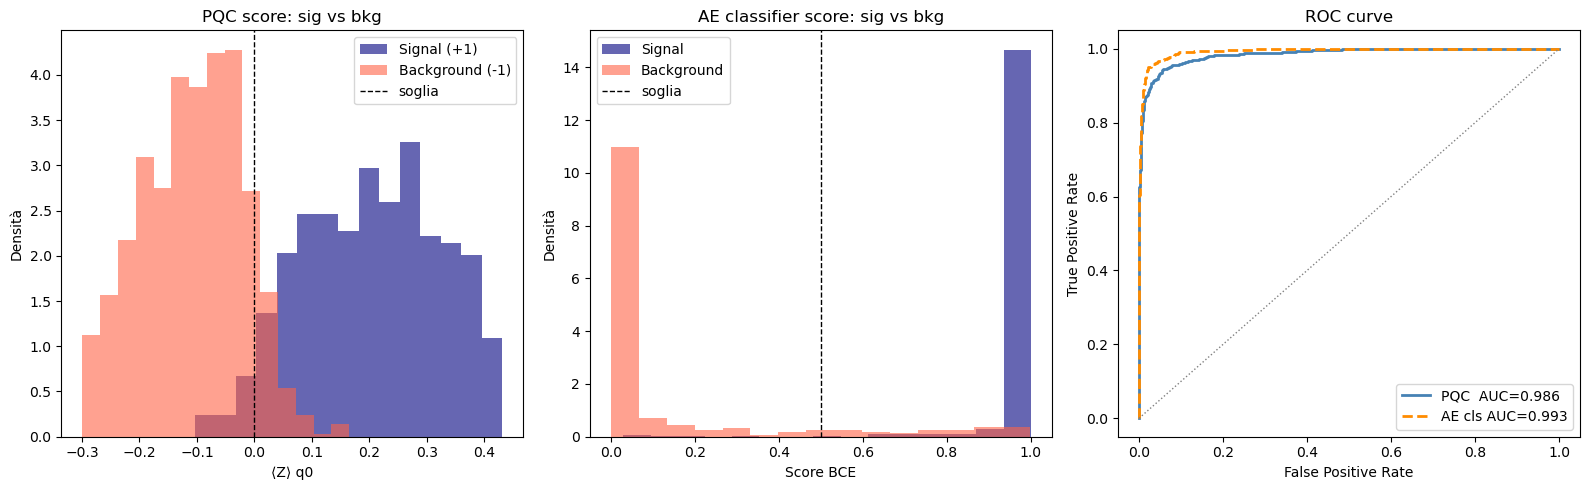

In [10]:
# TEST

test_predictions = [float(predict(weights, x)) for x in X_test]


# EVALUATION TEST

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

pred_labels = [1 if p >= 0 else -1 for p in test_predictions]
scores_np   = np.array([float(p) for p in test_predictions])
Y_test_np   = np.array(Y_test)
pred_np     = np.array(pred_labels)

accuracy  = np.mean(pred_np == Y_test_np)
test_cost = cost_function(weights, X_test, Y_test, batch_size)

# AUC (converti -1/+1 → 0/1 per sklearn)
Y_bin = ((Y_test_np + 1) / 2).astype(int)
s_bin = (scores_np + 1) / 2
auc   = roc_auc_score(Y_bin, s_bin)
fpr, tpr, _ = roc_curve(Y_bin, s_bin)

cm = confusion_matrix(Y_test_np, pred_np, labels=[1,-1])
TP, FN = cm[0,0], cm[0,1]
FP, TN = cm[1,0], cm[1,1]
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# AE classifier (dal modello classico)
print("")
print("")
print("  AE SINKCLASS — classificatore classico (BCE)")
with torch.no_grad():
    _, ae_scores, _ = model.forward(torch.tensor(X_te, dtype=torch.float32))
    ae_scores_np = ae_scores.cpu().numpy().flatten()
ae_pred  = (ae_scores_np >= 0.5).astype(int)
ae_acc   = np.mean(ae_pred == Y_te.astype(int))
ae_auc   = roc_auc_score(Y_te.astype(int), ae_scores_np)
print(f"  Accuracy AE classifier : {ae_acc*100:.2f}%")
print(f"  AUC      AE classifier : {ae_auc:.4f}")
print(f"  Score medio su signal  : {ae_scores_np[Y_te==1].mean():.4f}")
print(f"  Score medio su bkg     : {ae_scores_np[Y_te==0].mean():.4f}")

# valori PQC 
print("")
print("")
print("  PQC — classificatore quantistico")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  AUC       : {auc:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  Cost test : {test_cost:.4f}")
print("")
print(f"\n  Matrice di confusione (righe=vero, col=pred):")
print("")
print(f"               pred+1  pred-1")
print(f"  vero  +1  :  {TP:5d}   {FN:5d}")
print(f"  vero  -1  :  {FP:5d}   {TN:5d}")
print(f"\n  Score PQC medio su signal : {scores_np[Y_test_np== 1].mean():.4f}")
print(f"  Score PQC medio su bkg    : {scores_np[Y_test_np==-1].mean():.4f}")
print("")
print("")


# PLOT

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafico score PQC sig vs bkg
axes[0].hist(scores_np[Y_test_np== 1], bins=15, alpha=0.6,
             color="navy",   label="Signal (+1)", density=True)
axes[0].hist(scores_np[Y_test_np==-1], bins=15, alpha=0.6,
             color="tomato", label="Background (-1)", density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="soglia")
axes[0].set_title("PQC score: sig vs bkg")
axes[0].set_xlabel("⟨Z⟩ q0")
axes[0].set_ylabel("Densità")
axes[0].legend()

# Grafico score AE classifier sig vs bkg
axes[1].hist(ae_scores_np[Y_te==1], bins=15, alpha=0.6,
             color="navy",   label="Signal", density=True)
axes[1].hist(ae_scores_np[Y_te==0], bins=15, alpha=0.6,
             color="tomato", label="Background", density=True)
axes[1].axvline(0.5, color="black", linewidth=1, linestyle="--", label="soglia")
axes[1].set_title("AE classifier score: sig vs bkg")
axes[1].set_xlabel("Score BCE")
axes[1].set_ylabel("Densità")
axes[1].legend()

# 3. ROC curve AE e PQC
axes[2].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"PQC  AUC={auc:.3f}")
ae_fpr, ae_tpr, _ = roc_curve(Y_te.astype(int), ae_scores_np)
axes[2].plot(ae_fpr, ae_tpr, color="darkorange", linewidth=2,
             linestyle="--", label=f"AE cls AUC={ae_auc:.3f}")
axes[2].plot([0,1], [0,1], color="gray", linewidth=1, linestyle=":")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

Si stampa poi il circuito:

In [14]:
# STAMPA CIRCUITO

print(qml.draw(circuit)(weights, X_train))

0: ──RY(1.35)──RZ(1.81)──RY(0.98)──RZ(0.87)─╭IsingZZ(2.21)──RY(2.12)───────RZ(0.87)───── ···
1: ──RY(1.64)──RZ(2.70)──RY(1.00)──RZ(0.93)─╰IsingZZ(2.21)─╭IsingZZ(2.44)──RY(2.58)───── ···
2: ──RY(1.49)──RZ(2.21)──RY(1.00)──RZ(0.90)────────────────╰IsingZZ(2.44)─╭IsingZZ(2.42) ···
3: ──RY(1.63)──RZ(2.65)──RY(1.00)──RZ(0.93)───────────────────────────────╰IsingZZ(2.42) ···
4: ──RY(1.88)──RZ(3.52)──RY(0.95)──RZ(0.95)───────────────────────────────────────────── ···
5: ──RY(1.44)──RZ(2.06)──RY(0.99)──RZ(0.89)───────────────────────────────────────────── ···
6: ──RY(1.65)──RZ(2.72)──RY(1.00)──RZ(0.93)───────────────────────────────────────────── ···
7: ──RY(1.59)──RZ(2.52)──RY(1.00)──RZ(0.92)───────────────────────────────────────────── ···

0: ··· ────────────────╭IsingZZ(2.21)──RY(0.23)───────RZ(0.33)──────────────────── ···
1: ··· ──RZ(0.93)──────╰IsingZZ(2.21)─╭IsingZZ(2.44)──RY(0.05)───────RZ(-0.38)──── ···
2: ··· ──RY(2.33)───────RZ(0.90)──────╰IsingZZ(2.44)─╭IsingZZ(2.42)──RY(-0.38)───

L'algoritmo costituisce quindi un buon modello e sembra ottimizzare bene la loss function, ma gli indici di performance sul dataset di test mostrano ancora un margine di miglioramento e il circuito risulta essere molto dispendioso computazionalmente. \
Nel notebook successivo (VQAreuploading) si studia un nuovo tipo di encoding per far fronte al problema: il data re-uploading.